In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use("ggplot")

In [2]:
file_path = r"C:\Users\ajink\Downloads\kine trexa\online_retail_II.xlsx"

df_2009 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

# Merge both sheets

data = pd.concat([df_2009, df_2010], ignore_index=True)

data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
##Data Understanding

In [4]:
data.shape

(1067371, 8)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [6]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [7]:
data.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
#Data cleaning 

In [9]:
# Remove missing Customer IDs
data = data.dropna(subset=["Customer ID"])

# Remove cancelled invoices
data = data[~data["Invoice"].astype(str).str.startswith("C")]

# Remove Quantity <= 0
data = data[data["Quantity"] > 0]

# Remove Price <= 0
data = data[data["Price"] > 0]

In [10]:
# Data Cleaning Validation

data.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [11]:
#Create sales 

In [12]:
data["Sales"] = data["Quantity"] * data["Price"]

In [13]:
#Exploratory Data Analysis

In [14]:
# Top 10 Countries by Transactions

data["Country"].value_counts().head(10)

Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Spain               3719
Belgium             3068
Switzerland         3011
Portugal            2446
Australia           1812
Name: count, dtype: int64

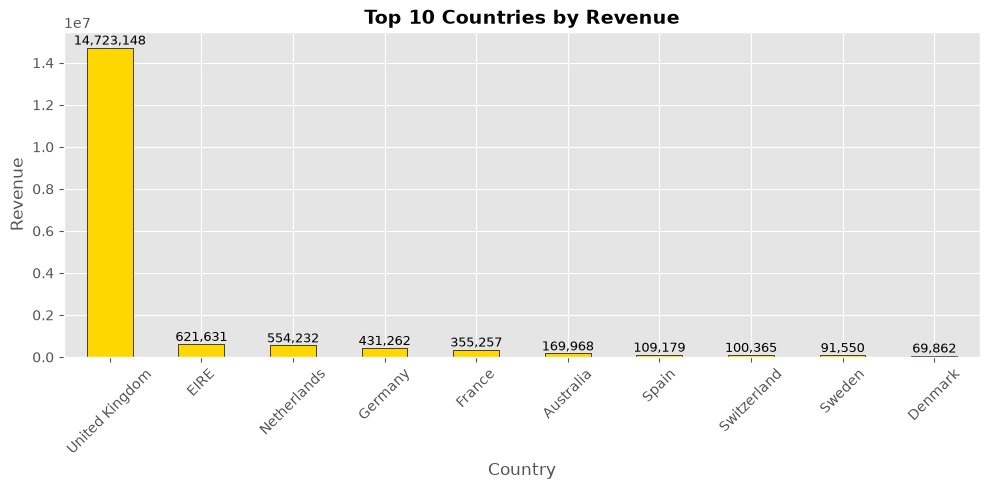

In [15]:
# Top 10 Countries by Revenue

top_country = (
    data.groupby("Country")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

ax = top_country.plot(kind="bar", figsize=(10,5), color="gold", edgecolor="black")

plt.title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

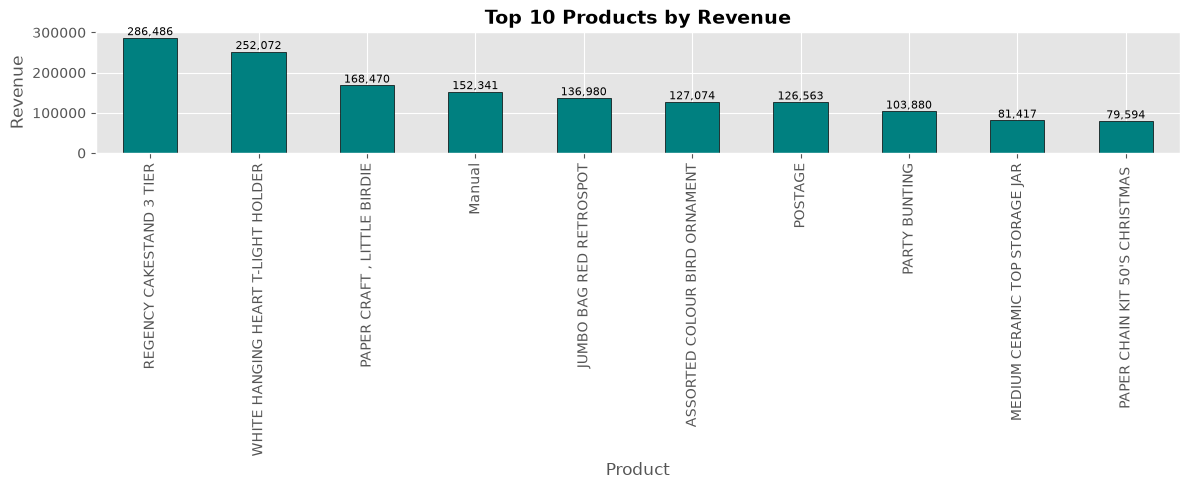

In [16]:
# Top 10 Products by Revenue

top_products = (
    data.groupby("Description")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

ax = top_products.plot(kind="bar", figsize=(12,5), color="teal", edgecolor="black")

plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

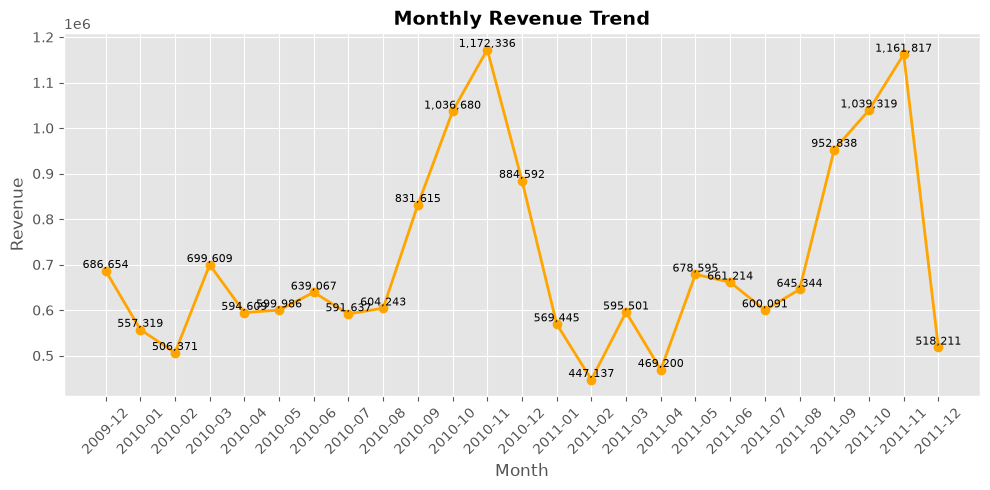

In [17]:
# Monthly Revenue Trend

data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data["Month"] = data["InvoiceDate"].dt.to_period("M")

monthly_sales = data.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values,
         marker="o", linewidth=2, color="orange")

plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Add labels
for x, y in zip(monthly_sales.index.astype(str), monthly_sales.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()